<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/04_time_series_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[⬅ Back to the course index](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/00_START_HERE.ipynb) · **Notebook 04 of the course**


# 🩺 Notebook 04 — Turning a timeline into features

> A sepsis patient is not a single snapshot — they are a **story that unfolds over hours**.
> A lactate of 4 that is *falling* is a very different patient from a lactate of 4 that is *climbing*.
> In this notebook we learn to turn that story — dozens of 4-hour blocks per patient — into the kind of
> numbers a machine-learning model can actually use, **without ever cheating by peeking into the future**.

This is the **heart of the course**. Feature engineering is where clinical judgement meets data science: the
transforms are simple pandas, but *which* feature to build is a bedside decision.

**What you'll learn**
- Why models usually want **one row per patient** (or leakage-safe **per-timestep** features), and how to build both
- The core time-series transforms — **lags, deltas, rolling windows, cumulative & expanding sums, time-since & counts, trends** — always **grouped by `icustayid`**
- How to spot and avoid **data leakage** (the single most common way medical ML fools itself)
- How to assemble the **patient-level table** that powers Notebooks 05–08

**⏱️ Time:** ≈80 min  ·  **Prerequisites:** Notebooks 01–03 (pandas, cleaning, EDA)


## ⚙️ Run me first

The cell below is the **standard workshop setup** (identical in every notebook). It installs anything missing,
sets a clean plotting style, and defines `load_csv(...)`. Just run it — no need to read it line by line.

In [1]:
# === ⚙️  Workshop setup — run this cell first ===============================
# Works in Google Colab and in local Jupyter. Installs anything missing, sets a
# clean plotting style, and gives you helpers to load the data.
# (This cell is identical in every notebook of the course.)
import importlib.util, subprocess, sys, os, random, warnings
warnings.filterwarnings("ignore")

# --- reproducibility: everyone in the room gets the same numbers ---------------
RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)

# 📥 Where the workshop data comes from — already set up for you, nothing to do.
# The data downloads automatically the first time you need it. If you were given a
# different link, just paste it in place of the one below. These forms all work:
#   • a Google-Drive folder link      • a Drive / Dropbox / OneDrive file link
#   • a folder URL ending in "/"      • a link straight to a .zip
# Set it to "" if you would rather upload the CSVs by hand.
# (The data is not in the GitHub repo: it is real de-identified patient data covered
#  by a data use agreement and may not be redistributed openly.)
WORKSHOP_DATA_URL = os.environ.get(
    "WORKSHOP_DATA_URL",
    "https://drive.google.com/drive/folders/1y7CparhrqdlCAZq6xQlj8fZda394fniD")

def _ensure(pkgs):
    missing = [pip for mod, pip in pkgs.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print("Installing:", *missing)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing])
_ensure({"numpy":"numpy","pandas":"pandas","sklearn":"scikit-learn",
         "matplotlib":"matplotlib","seaborn":"seaborn","shap":"shap","xgboost":"xgboost"})

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
np.random.seed(RANDOM_STATE)          # seeds the legacy global np.random.* calls
RNG = np.random.default_rng(RANDOM_STATE)   # the modern generator — use this one
pd.set_option("display.max_columns", 120); pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5); plt.rcParams["figure.dpi"] = 110

# Every model, split and resample in this course passes random_state=RANDOM_STATE, so
# your numbers should match your neighbour's exactly. (Different library *versions* can
# still shift the last decimal — that is normal and not a mistake on your part.)

# --- data loading: works locally AND remembers your upload across notebooks -----
_CACHE = {"dir": "unset"}   # memo so we only touch Google Drive once per session

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def _drive_cache():
    """In Google Colab, mount Drive ONCE and return a persistent folder. A file you
    upload in one notebook is saved here, so every other notebook opens it automatically
    — no re-uploading. Returns None outside Colab, or if you decline to connect Drive."""
    if _CACHE["dir"] != "unset":
        return _CACHE["dir"]
    result = None
    if _in_colab():
        try:
            from google.colab import drive
            if not os.path.ismount("/content/drive"):
                drive.mount("/content/drive")
            result = "/content/drive/MyDrive/sepsis_workshop_data"
            os.makedirs(result, exist_ok=True)
        except Exception:
            result = None
    _CACHE["dir"] = result
    return result

def _find(name):
    """Look for the file on disk. Deliberately does NOT touch Google Drive, so the normal
    path never triggers an authorisation popup."""
    for p in [name, f"data/{name}", f"../data/{name}", f"workshop/data/{name}"]:
        if os.path.exists(p):
            return p
    return None

def _find_in_drive(name):
    """Only used as a fallback, because it mounts Drive (and that means a popup)."""
    cache = _drive_cache()
    if cache:
        p = os.path.join(cache, name)
        if os.path.exists(p):
            return p
    return None

def _direct_url(u):
    """Turn an ordinary Google-Drive / Dropbox / OneDrive *share* link into one that a
    plain HTTP client can actually download, so you can paste the link you were given."""
    import re
    m = (re.search(r"drive\.google\.com/file/d/([\w-]+)", u)
         or re.search(r"drive\.google\.com/(?:open|uc)\?(?:export=\w+&)?id=([\w-]+)", u))
    if m:
        return f"https://drive.google.com/uc?export=download&id={m.group(1)}"
    if "dropbox.com" in u:
        return u.split("?")[0] + "?dl=1"
    if "sharepoint.com" in u or "1drv.ms" in u:
        return u + ("&" if "?" in u else "?") + "download=1"
    return u

def _fetch(url, dest):
    import urllib.request, shutil as _sh
    req = urllib.request.Request(_direct_url(url), headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=120) as r, open(dest, "wb") as f:
        _sh.copyfileobj(r, f)

_FOLDER = {"done": False}

def _gdrive_folder(name):
    """WORKSHOP_DATA_URL points at a Google-Drive *folder*: fetch it once with gdown
    (a folder cannot be downloaded with a plain HTTP request), then serve files from it."""
    dest = "_workshop_data"
    if not _FOLDER["done"]:
        _ensure({"gdown": "gdown"})
        import gdown
        print("⬇  fetching the workshop data from Google Drive (just once) …")
        gdown.download_folder(url=WORKSHOP_DATA_URL, output=dest, quiet=True, use_cookies=False)
        _FOLDER["done"] = True
    for root, _dirs, files in os.walk(dest):
        if name in files:
            return os.path.join(root, name)
    return None

def _try_download(name):
    """Fetch the data from WORKSHOP_DATA_URL, if one was configured."""
    u = (WORKSHOP_DATA_URL or "").strip()
    if not u:
        return None
    try:
        if "/drive/folders/" in u:
            return _gdrive_folder(name)
        if u.lower().split("?")[0].endswith(".zip"):
            import zipfile
            bundle = "_workshop_data.zip"
            if not os.path.exists(bundle):
                print("⬇  downloading the workshop data bundle …")
                _fetch(u, bundle)
            with zipfile.ZipFile(bundle) as z:      # flatten any folder inside the zip
                for member in z.namelist():
                    if os.path.basename(member) == name:
                        with z.open(member) as src, open(name, "wb") as dst:
                            dst.write(src.read())
                        return name
            print(f"  ({name} was not inside the bundle)")
            return None
        print(f"⬇  downloading {name} …")
        _fetch(u.rstrip("/") + "/" + name, name)
        return name
    except Exception as e:
        print(f"  (download failed: {e})")
        for leftover in (name, "_workshop_data.zip"):
            if os.path.exists(leftover) and os.path.getsize(leftover) == 0:
                os.remove(leftover)
        return None

def _cache_to_drive(name, data):
    cache = _drive_cache()
    if cache:
        dest = os.path.join(cache, name)
        data.to_csv(dest, index=False)
        print(f"  💾 saved to Google Drive ({dest}) — no need to fetch it again.")

def load_csv(name):
    """Load a data CSV: looks on disk, then downloads it from WORKSHOP_DATA_URL, then checks
    your Google-Drive cache, and only as a last resort asks you to upload it — in which case
    it saves a copy to Drive so you never have to upload it twice."""
    p = _find(name)                       # 1. already on disk?
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    p = _try_download(name)               # 2. the built-in download link
    if p:
        print(f"✓ loaded {name}")
        return pd.read_csv(p)
    p = _find_in_drive(name)              # 3. a copy you saved on a previous run
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    try:                                  # 4. last resort: upload it by hand
        from google.colab import files
        print(f"⤴  Upload {name} just once — I'll save it so the other notebooks open it automatically:")
        up = files.upload()
        fname = list(up.keys())[0]
        data = pd.read_csv(fname)
        _cache_to_drive(name, data)
        return data
    except Exception:
        raise FileNotFoundError(
            f"Could not find {name}. Either paste your download link into WORKSHOP_DATA_URL at "
            f"the top of this cell, or put the CSV next to this notebook / in a data/ folder."
        )


## 📥 Load the time-series file — and **sort it first**

Every transform in this notebook (lag, delta, rolling, cumulative…) reads rows **in order**. If the rows are
out of order, "the previous block" is meaningless. So the very first thing we do — before anything else — is
**sort by patient, then by time block**. This is the single most important habit in time-series work.

We also `reset_index(drop=True)` to give ourselves a clean, gapless row index; a couple of the transforms below
rely on that to line results back up correctly.

In [2]:
df = load_csv("sepsis_timeseries.csv")

# 🔑 GOLDEN RULE: sort by patient, then by time, BEFORE any time-series transform.
df = df.sort_values(["icustayid", "bloc"]).reset_index(drop=True)

print("Rows, columns:", df.shape)
print("Unique ICU stays:", df["icustayid"].nunique())
df[["icustayid", "bloc", "HR", "MeanBP", "Arterial_lactate", "output_step", "SOFA", "morta_90"]].head(8)


✓ loaded data/sepsis_timeseries.csv
Rows, columns: (37704, 53)
Unique ICU stays: 1696


,icustayid,bloc,HR,MeanBP,Arterial_lactate,output_step,SOFA,morta_90
0,30003226,1,83.40,88.00,2.00,65.0,1,0
1,30003226,2,69.71,87.29,1.10,65.0,7,0
2,30003226,3,66.25,101.50,0.60,80.0,6,0
3,30003226,4,72.12,87.25,1.00,35.0,6,0
4,30003226,5,75.25,104.12,0.80,62.0,4,0
5,30003226,6,64.43,106.86,0.70,40.0,4,0
6,30003226,7,75.00,95.75,0.97,64.0,6,0
7,30003226,8,69.20,96.00,0.97,60.0,6,0


## 🧼 Clean first — so every feature is trustworthy

In Notebook 02 we learned to fix impossible vitals, the temperature trap, and skewed-lab outliers.
**Feature engineering is only as good as the data underneath it** — a single erroneous lactate of 25
would ruin a *lactate-slope* feature. So before we engineer anything, we apply that same cleaning recipe
**once, here**, and every transform below runs on the clean result.

In [3]:
def clean_timeseries(d):
    """The Notebook-02 cleaning recipe in one function (past-aware, deletes no rows)."""
    d = d.copy()
    # 1) temperature: prefer plausible Celsius, else convert plausible Fahrenheit
    tc = d["Temp_C"].where(d["Temp_C"].between(25, 45))
    tf = d["Temp_F"].where(d["Temp_F"].between(90, 110))
    d["Temp_C"] = tc.fillna((tf - 32) * 5/9)
    # 2) impossible vitals -> NaN, then per-patient forward/back-fill (past first)
    ranges = {"HR":(20,300), "RR":(3,80), "SpO2":(30,100), "MeanBP":(20,220),
              "SysBP":(40,300), "DiaBP":(20,200), "Temp_C":(25,45)}
    for c,(lo,hi) in ranges.items():
        d[c] = d[c].where((d[c] >= lo) & (d[c] <= hi))
    for c in ranges:
        d[c] = d.groupby("icustayid")[c].ffill()
        d[c] = d.groupby("icustayid")[c].bfill()
    # 3) winsorise skewed labs (clip 1st-99th pct) so a stray value can't drive a feature
    for c in ["Arterial_lactate","Creatinine","BUN","WBC_count","Platelets_count","INR","Glucose"]:
        lo, hi = d[c].quantile(0.01), d[c].quantile(0.99)
        d[c] = d[c].clip(lo, hi)
    # 4) drop exact-duplicate rows
    return d.drop_duplicates().reset_index(drop=True)

lactate_max_before = df["Arterial_lactate"].max()
df = clean_timeseries(df)
print("After cleaning:", df.shape, "| duplicate rows:", int(df.duplicated().sum()))
print(f"Max lactate: {lactate_max_before:.1f} (raw)  ->  {df['Arterial_lactate'].max():.1f} (winsorised)")
print(f"Max creatinine now: {df['Creatinine'].max():.1f}")

After cleaning: (37698, 53) | duplicate rows: 0


Max lactate: 20.2 (raw)  ->  7.0 (winsorised)
Max creatinine now: 12.4


> **🧠 Clinical takeaway.** One row = one patient during one 4-hour window. A patient with a 5-day stay has
> ≈30 rows. Sorting by `["icustayid", "bloc"]` guarantees that "the row above" is genuinely *this same patient,
> four hours earlier* — never a different patient and never the future.

### 👤 Two patients to follow

To *see* what each transform does, we'll follow two real stays through the whole notebook: one patient who
**died within 90 days** and one who **survived**. We pick them programmatically (longest well-measured stays)
so the choice is reproducible.

In [4]:
g_size   = df.groupby("icustayid").size()
g_lacobs = df.groupby("icustayid")["Arterial_lactate"].apply(lambda s: s.notna().sum())
g_mort   = df.groupby("icustayid")["morta_90"].max()
cand = pd.DataFrame({"n_blocs": g_size, "lactate_obs": g_lacobs, "died": g_mort})
cand = cand[(cand["n_blocs"].between(18, 36)) & (cand["lactate_obs"] >= 10)]

DEMO_DIED = int(cand[cand["died"] == 1].sort_values("n_blocs", ascending=False).index[0])
DEMO_SURV = int(cand[cand["died"] == 0].sort_values("n_blocs", ascending=False).index[0])
print(f"Demo patient who DIED    : {DEMO_DIED}  ({int(cand.loc[DEMO_DIED,'n_blocs'])} blocks)")
print(f"Demo patient who SURVIVED: {DEMO_SURV}  ({int(cand.loc[DEMO_SURV,'n_blocs'])} blocks)")

def one(stay):
    """Return one patient's stay, sorted by time block."""
    return df[df["icustayid"] == stay].sort_values("bloc")


Demo patient who DIED    : 36714916  (36 blocks)
Demo patient who SURVIVED: 39179485  (36 blocks)


## 🎯 Why engineer features at all? Two framings

Machine-learning models (logistic regression, random forests, XGBoost) expect a **rectangular table**: a fixed
set of columns, and — usually — **one row per example**. But our data has a *variable* number of rows per
patient. There are two legitimate ways to reconcile this, and they answer **different clinical questions**:

| Framing | One row = | Predicts | Rule about time |
|---|---|---|---|
| **A. Whole-stay (patient-level)** | one ICU stay | outcome *of the stay* (e.g. 90-day mortality) | may use the **entire** stay |
| **B. Early-warning (per-timestep)** | one patient at one 4-h block | will something happen **soon**? | may use **only the past** up to that block |

Framing **A** summarises each stay into features like *mean lactate*, *max SOFA*, *last creatinine* — that's the
`sepsis_patients.csv` table we build at the end, and what Notebooks 05–08 use.

Framing **B** builds features *at every block* using only history so far (lags, rolling means, cumulative counts)
— that's how real bedside early-warning scores work.

> **⚠️ The trap that connects them:** a feature that is perfectly fine in Framing A (e.g. *max lactate over the
> whole stay*) is **leakage** in Framing B, because at hour 8 you cannot know the maximum that only occurs at
> hour 40. Keep asking: *"Would I actually have this number at the moment of prediction?"*

## ⏮️ Lags — "what was it last time?"

A **lag** is simply the value from an earlier block. `groupby("icustayid")[col].shift(1)` moves each patient's
column **down by one row**, *within that patient only*. The `shift` respects patient boundaries: the first block
of each stay has **no** previous value, so its lag is `NaN` — exactly right, we didn't borrow from the patient
above.

Lags are the raw material for almost everything else: a *delta* is just `value − lag`.

In [5]:
# previous-block values, computed independently for every patient
df["HR_lag1"]      = df.groupby("icustayid")["HR"].shift(1)
df["lactate_lag1"] = df.groupby("icustayid")["Arterial_lactate"].shift(1)

# look at one patient — notice the FIRST block's lag is NaN (no history yet)
one(DEMO_DIED)[["bloc", "HR", "HR_lag1", "Arterial_lactate", "lactate_lag1"]].head(6)


,bloc,HR,HR_lag1,Arterial_lactate,lactate_lag1
25268,1,103.38,NaN,2.40,NaN
25269,2,93.20,103.38,2.56,2.40
25270,3,98.30,93.20,1.40,2.56
25271,4,106.30,98.30,1.40,1.40
25272,5,108.60,106.30,1.40,1.40
25273,6,116.54,108.60,1.40,1.40


Notice how `HR_lag1` in each row equals `HR` from the row **above** — but only within the same patient. Let's
visualise the shift for our demo patient: the lagged line is the raw line slid one block to the right.

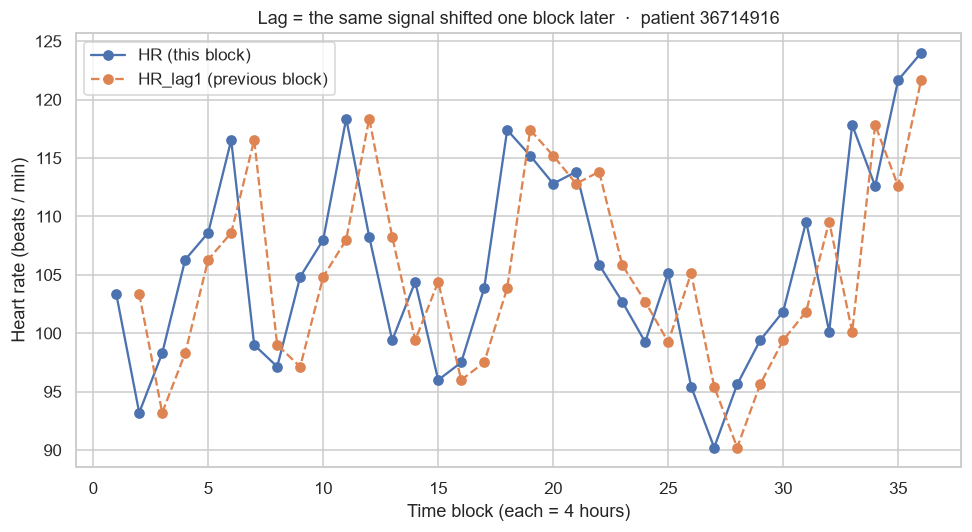

In [6]:
p = one(DEMO_DIED)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(p["bloc"], p["HR"],      marker="o", label="HR (this block)")
ax.plot(p["bloc"], p["HR_lag1"], marker="o", linestyle="--", label="HR_lag1 (previous block)")
ax.set_title(f"Lag = the same signal shifted one block later  ·  patient {DEMO_DIED}")
ax.set_xlabel("Time block (each = 4 hours)")
ax.set_ylabel("Heart rate (beats / min)")
ax.legend()
plt.tight_layout(); plt.show()


*Interpretation:* the dashed line is the solid line delayed by one 4-hour block. The **gap between them** at
any point is the change from the last reading — which is exactly the *delta* we build next.

## 📈 Deltas & rate of change — "which way is it heading?"

The **trend** often matters more than the absolute value. `diff()` gives the change since the previous block; it
is grouped so it never crosses patient boundaries. Because each block is **4 hours**, dividing by 4 turns a
per-block change into a **per-hour rate**.

- `col.diff()` → change vs previous block (same as `col − col.shift(1)`)
- `diff().diff()` → **second** difference = is the change itself accelerating?
- `diff() / 4` → change **per hour**

In [7]:
gb = df.groupby("icustayid", group_keys=False)

df["lactate_delta"]  = gb["Arterial_lactate"].diff()          # change since last block
df["lactate_rate_h"] = df["lactate_delta"] / 4.0              # change per HOUR (block = 4 h)

# second difference: diff of the (already grouped) first difference — still per patient
df["HR_delta"]  = gb["HR"].diff()
df["HR_accel"]  = df.groupby("icustayid")["HR_delta"].diff()  # is HR change speeding up?

one(DEMO_DIED)[["bloc", "Arterial_lactate", "lactate_delta", "lactate_rate_h"]].head(7)


,bloc,Arterial_lactate,lactate_delta,lactate_rate_h
25268,1,2.40,NaN,NaN
25269,2,2.56,0.16,0.0400
25270,3,1.40,-1.16,-0.2900
25271,4,1.40,0.00,0.0000
25272,5,1.40,0.00,0.0000
25273,6,1.40,0.00,0.0000
25274,7,3.21,1.81,0.4525


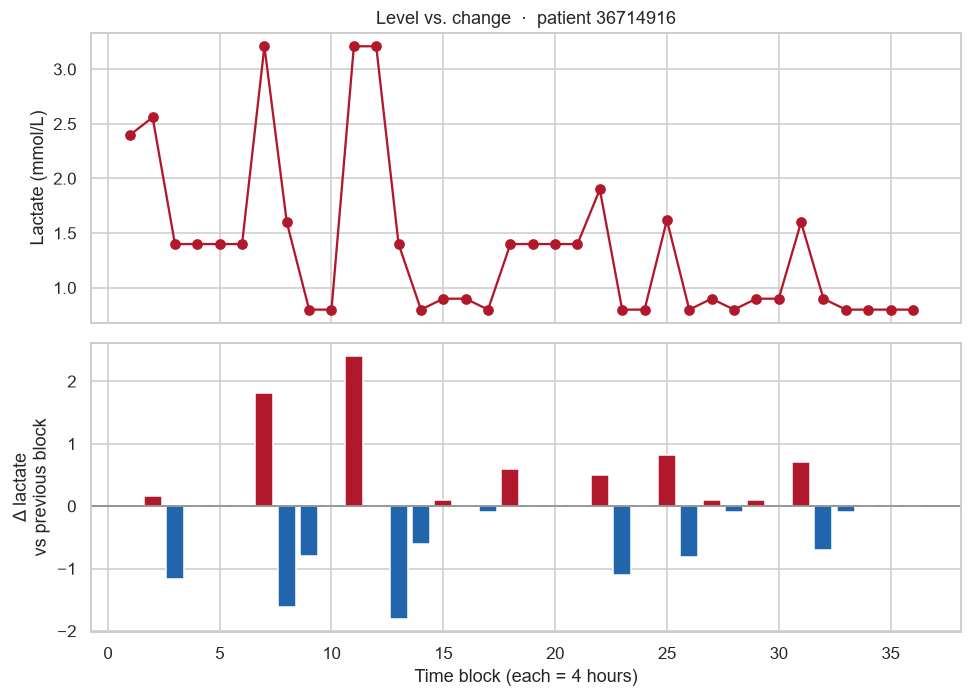

In [8]:
p = one(DEMO_DIED)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True)
a1.plot(p["bloc"], p["Arterial_lactate"], marker="o", color="#b2182b")
a1.set_ylabel("Lactate (mmol/L)")
a1.set_title(f"Level vs. change  ·  patient {DEMO_DIED}")

colors = ["#2166ac" if (v <= 0 or np.isnan(v)) else "#b2182b" for v in p["lactate_delta"]]
a2.bar(p["bloc"], p["lactate_delta"], color=colors)
a2.axhline(0, color="grey", lw=1)
a2.set_ylabel("Δ lactate\nvs previous block")
a2.set_xlabel("Time block (each = 4 hours)")
plt.tight_layout(); plt.show()


> **🧠 Clinical takeaway.** Red bars = **rising** lactate (worsening tissue perfusion); blue = falling
> (responding to resuscitation). A model given only *level* sees a snapshot; a model given *level + delta* can
> tell a recovering patient from a deteriorating one at the **same** lactate. That is often where predictive
> power hides.

## 🪟 Rolling windows — smoothing the noise

Single readings are noisy (a cuff artifact, a restless patient). A **rolling window** averages the last *k*
blocks, sliding forward one block at a time. It smooths noise **and** — with `.std()` — measures *instability*.

Because 1 block = 4 hours:

| window `k` | covers | reads as |
|---|---|---|
| 3 | ≈12 hours | short-term trend |
| 6 | ≈24 hours | a full day |

The pandas idiom has one subtlety. `groupby(...).rolling(k)` returns a result indexed by **(patient, row)** — a
two-level index. We peel off the patient level with `.reset_index(level=0, drop=True)` so it lines back up with
`df`. We also pass `min_periods=1` so early blocks (before the window is full) still get a value instead of
`NaN`.

In [9]:
def roll(col, k, how):
    """Leakage-safe rolling stat, per patient, aligned back to df's index."""
    r = df.groupby("icustayid")[col].rolling(k, min_periods=1)
    r = getattr(r, how)()                      # .mean() / .max() / .min() / .std()
    return r.reset_index(level=0, drop=True)   # drop the patient index level

df["HR_roll3_mean"]   = roll("HR", 3, "mean")   # ~12 h average
df["HR_roll3_std"]    = roll("HR", 3, "std")    # ~12 h instability
df["MeanBP_roll6_min"] = roll("MeanBP", 6, "min")  # worst BP in the last ~24 h

one(DEMO_DIED)[["bloc", "HR", "HR_roll3_mean", "HR_roll3_std"]].head(6)


,bloc,HR,HR_roll3_mean,HR_roll3_std
25268,1,103.38,103.380000,NaN
25269,2,93.20,98.290000,7.198347
25270,3,98.30,98.293333,5.090003
25271,4,106.30,99.266667,6.603282
25272,5,108.60,104.400000,5.406478
25273,6,116.54,110.480000,5.372634


Raw signal vs. its rolling mean — the rolling line is calmer and reveals the underlying drift. The shaded band
is ± the rolling **standard deviation** (how jumpy the last 12 h were).

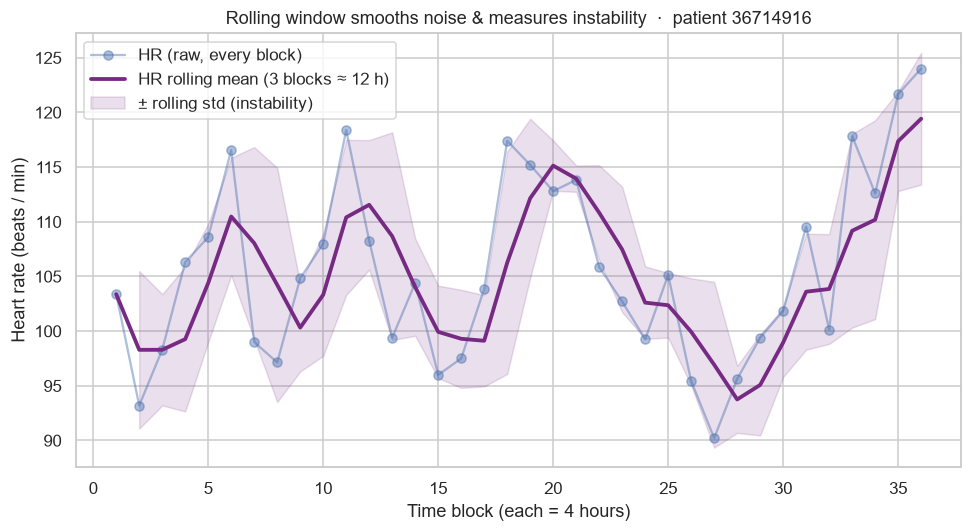

In [10]:
p = one(DEMO_DIED)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(p["bloc"], p["HR"], marker="o", alpha=0.45, label="HR (raw, every block)")
ax.plot(p["bloc"], p["HR_roll3_mean"], color="#762a83", lw=2.5, label="HR rolling mean (3 blocks ≈ 12 h)")
ax.fill_between(p["bloc"],
                p["HR_roll3_mean"] - p["HR_roll3_std"],
                p["HR_roll3_mean"] + p["HR_roll3_std"],
                color="#762a83", alpha=0.15, label="± rolling std (instability)")
ax.set_title(f"Rolling window smooths noise & measures instability  ·  patient {DEMO_DIED}")
ax.set_xlabel("Time block (each = 4 hours)"); ax.set_ylabel("Heart rate (beats / min)")
ax.legend()
plt.tight_layout(); plt.show()


### Short window vs long window

The window length is a **dial**, not a fixed rule. Short windows react fast (good for catching sudden crashes);
long windows are stable (good for slow trends). Here is the same MeanBP smoothed two ways.

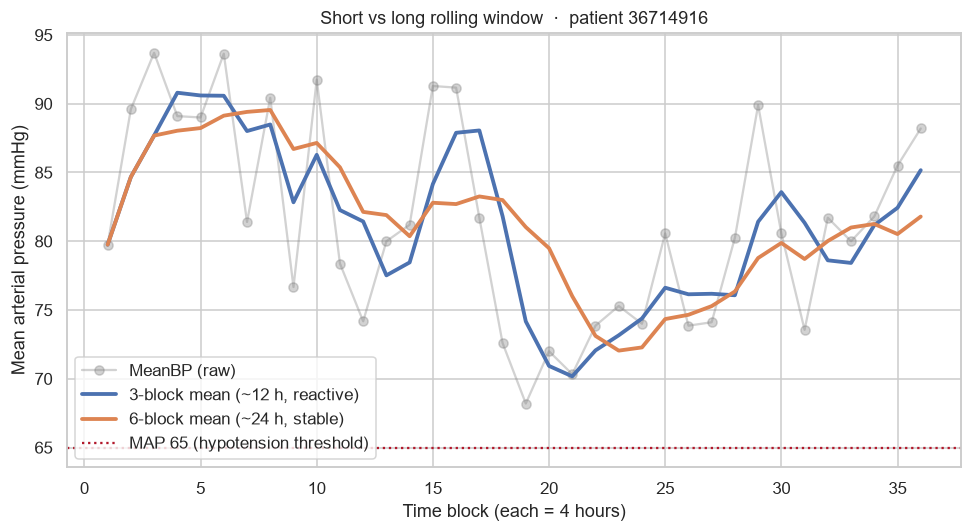

In [11]:
df["MeanBP_roll3_mean"] = roll("MeanBP", 3, "mean")
df["MeanBP_roll6_mean"] = roll("MeanBP", 6, "mean")

p = one(DEMO_DIED)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(p["bloc"], p["MeanBP"], marker="o", alpha=0.35, color="grey", label="MeanBP (raw)")
ax.plot(p["bloc"], p["MeanBP_roll3_mean"], lw=2.5, label="3-block mean (~12 h, reactive)")
ax.plot(p["bloc"], p["MeanBP_roll6_mean"], lw=2.5, label="6-block mean (~24 h, stable)")
ax.axhline(65, color="#b2182b", ls=":", label="MAP 65 (hypotension threshold)")
ax.set_title(f"Short vs long rolling window  ·  patient {DEMO_DIED}")
ax.set_xlabel("Time block (each = 4 hours)"); ax.set_ylabel("Mean arterial pressure (mmHg)")
ax.legend()
plt.tight_layout(); plt.show()


> **🧠 Clinical takeaway.** Rolling **means** answer *"what's the trend?"*; rolling **std** answers *"how
> unstable is this patient?"* — and instability itself predicts badness. Rolling **min** over ≈24 h captures the
> *worst* MAP the patient reached recently, which a single spot reading might miss.

## ➕ Cumulative features — "how much so far?"

Some quantities only make sense **added up over time**: total urine, total fluids in, the *worst* SOFA reached so
far. `cumsum()` and `cummax()` are grouped so each patient's running total **restarts at zero**. These are
naturally **leakage-safe**: a running total at block *t* uses only blocks 1…*t*.

Our data even ships one for you — `cumulated_balance` is already a cumulative sum of net fluid. Let's rebuild the
urine total from `output_step` to see the machinery.

In [12]:
df["urine_cum"]   = df.groupby("icustayid")["output_step"].cumsum()   # running urine out (mL)
df["fluid_in_cum"] = df.groupby("icustayid")["input_step"].cumsum()   # running fluids in (mL)
df["SOFA_cummax"]  = df.groupby("icustayid")["SOFA"].cummax()         # worst organ failure so far

one(DEMO_DIED)[["bloc", "output_step", "urine_cum", "SOFA", "SOFA_cummax", "cumulated_balance"]].head(7)


,bloc,output_step,urine_cum,SOFA,SOFA_cummax,cumulated_balance
25268,1,125.0,125.0,4,4,162668.0
25269,2,275.0,400.0,4,4,162499.0
25270,3,500.0,900.0,5,5,162073.0
25271,4,420.0,1320.0,4,5,162971.0
25272,5,1040.0,2360.0,5,5,168028.0
25273,6,1295.0,3655.0,4,5,172700.0
25274,7,200.0,3855.0,4,5,178470.0


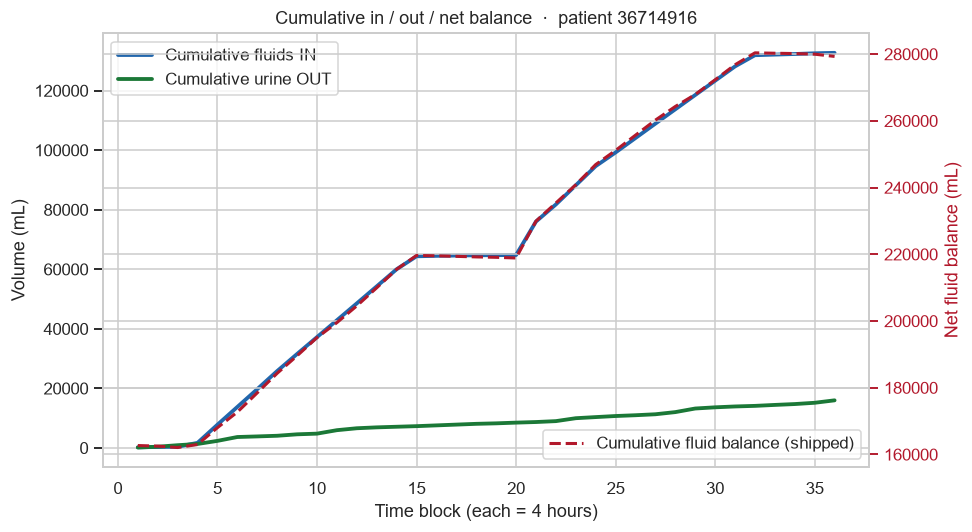

In [13]:
p = one(DEMO_DIED)
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(p["bloc"], p["fluid_in_cum"], color="#2166ac", lw=2.5, label="Cumulative fluids IN")
ax1.plot(p["bloc"], p["urine_cum"],    color="#1b7837", lw=2.5, label="Cumulative urine OUT")
ax1.set_xlabel("Time block (each = 4 hours)")
ax1.set_ylabel("Volume (mL)")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(p["bloc"], p["cumulated_balance"], color="#b2182b", ls="--", lw=2, label="Cumulative fluid balance (shipped)")
ax2.set_ylabel("Net fluid balance (mL)", color="#b2182b")
ax2.tick_params(axis="y", colors="#b2182b")
ax2.legend(loc="lower right")
ax1.set_title(f"Cumulative in / out / net balance  ·  patient {DEMO_DIED}")
plt.tight_layout(); plt.show()


> **🧠 Clinical takeaway.** A widening gap between fluids in and urine out — a **positive** cumulative balance —
> means the patient is retaining fluid, which in sepsis is associated with worse outcomes. `cummax` of SOFA gives
> *"the sickest this patient has been so far"*, a monotone feature that never forgets a bad spell.

## 🌱 Expanding windows — "the average so far"

A rolling window looks back a *fixed* number of blocks. An **expanding** window looks back over **everything up to
now** — it grows one block at a time. `expanding().mean()` is the running average; it is the leakage-safe cousin
of the whole-stay mean, because at block *t* it has only seen blocks 1…*t*.

In [14]:
def expand(col, how="mean"):
    r = getattr(df.groupby("icustayid")[col].expanding(), how)()
    return r.reset_index(level=0, drop=True)

df["MeanBP_expmean"] = expand("MeanBP", "mean")   # mean MAP so far
df["lactate_expmax"] = expand("Arterial_lactate", "max")  # highest lactate SO FAR (leakage-safe)

one(DEMO_DIED)[["bloc", "MeanBP", "MeanBP_expmean"]].head(6)


,bloc,MeanBP,MeanBP_expmean
25268,1,79.75,79.750000
25269,2,89.60,84.675000
25270,3,93.70,87.683333
25271,4,89.10,88.037500
25272,5,89.00,88.230000
25273,6,93.64,89.131667


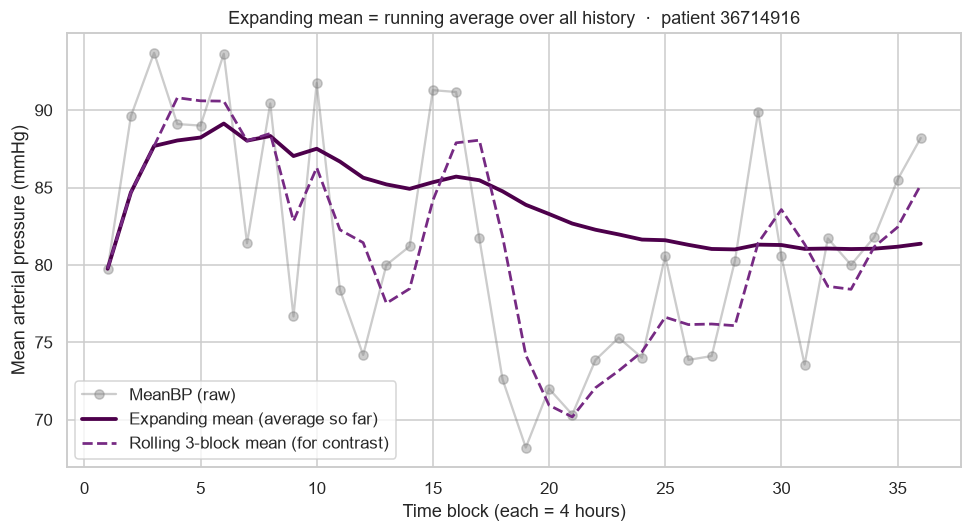

In [15]:
p = one(DEMO_DIED)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(p["bloc"], p["MeanBP"], marker="o", alpha=0.4, color="grey", label="MeanBP (raw)")
ax.plot(p["bloc"], p["MeanBP_expmean"], color="#4d004b", lw=2.5, label="Expanding mean (average so far)")
ax.plot(p["bloc"], p["MeanBP_roll3_mean"], color="#762a83", lw=1.8, ls="--", label="Rolling 3-block mean (for contrast)")
ax.set_title(f"Expanding mean = running average over all history  ·  patient {DEMO_DIED}")
ax.set_xlabel("Time block (each = 4 hours)"); ax.set_ylabel("Mean arterial pressure (mmHg)")
ax.legend()
plt.tight_layout(); plt.show()


*Interpretation:* the expanding mean (solid) is smooth and settles down as evidence accumulates — early on it
swings, later it barely moves because one new block is a small fraction of the history. The rolling mean (dashed)
stays responsive because it always forgets the distant past.

## ⏱️ Time-since & event counts — turning history into a tally

Clinicians reason with counts and durations: *"third hypotensive episode"*, *"on pressors for 12 hours"*,
*"day 2 of the stay"*. We can build these directly.

- **Hours since admission** — subtract each patient's first `timestep` (remember: intervals are real 4-h gaps).
- **Count of hypotensive blocks so far** — a boolean `MeanBP < 65`, then a grouped `cumsum`.
- **Fraction of time on vasopressors so far** — cumulative vaso-blocks ÷ blocks elapsed.

In [16]:
# hours since this patient's first block (transform keeps df's shape)
df["hours_since_admit"] = df.groupby("icustayid")["timestep"].transform(lambda s: (s - s.min()) / 3600.0)

# running count of hypotensive (MAP < 65) blocks — cumsum of a boolean, per patient
df["hypo_flag"]  = (df["MeanBP"] < 65).astype(int)
df["hypo_count"] = df.groupby("icustayid")["hypo_flag"].cumsum()

# fraction of blocks SO FAR that had any vasopressor
df["block_num"]      = df.groupby("icustayid").cumcount() + 1          # 1,2,3,... within stay
df["on_vaso"]        = (df["max_dose_vaso"] > 0).astype(int)
df["vaso_blocks"]    = df.groupby("icustayid")["on_vaso"].cumsum()
df["vaso_frac_sofar"] = df["vaso_blocks"] / df["block_num"]

one(DEMO_DIED)[["bloc", "hours_since_admit", "MeanBP", "hypo_count", "on_vaso", "vaso_frac_sofar"]].head(8)


,bloc,hours_since_admit,MeanBP,hypo_count,on_vaso,vaso_frac_sofar
25268,1,0.0,79.75,0,1,1.000000
25269,2,4.0,89.60,0,1,1.000000
25270,3,8.0,93.70,0,1,1.000000
25271,4,12.0,89.10,0,0,0.750000
25272,5,16.0,89.00,0,0,0.600000
25273,6,20.0,93.64,0,0,0.500000
25274,7,24.0,81.40,0,0,0.428571
25275,8,28.0,90.43,0,0,0.375000


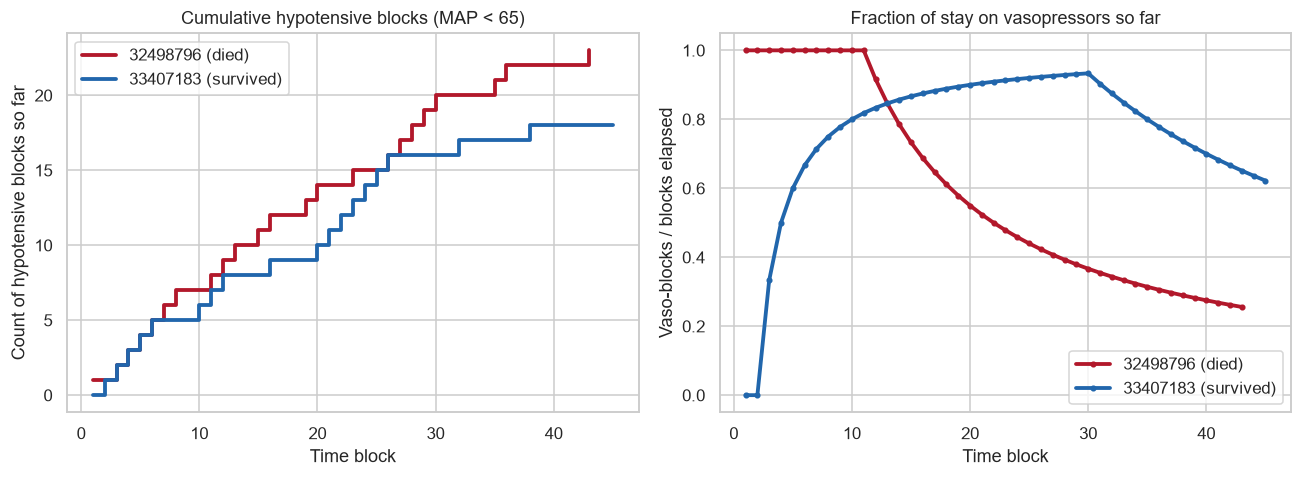

In [17]:
# pick two patients who ACTUALLY experience these events, so BOTH tallies are visible
evt = df.groupby("icustayid").agg(hypo=("hypo_flag","sum"), vaso=("on_vaso","sum"),
                                  n=("bloc","size"), died=("morta_90","max"))
evt = evt[evt["n"].between(12, 45)]
def pick(died):
    sub = evt[(evt.died == died) & (evt.vaso >= 1) & (evt.hypo >= 1)]
    if len(sub) == 0:
        sub = evt[evt.died == died]
    return sub.sort_values(["hypo", "vaso"], ascending=False).index[0]
ex_died, ex_surv = pick(1), pick(0)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
for stay, name, c in [(ex_died, "died", "#b2182b"), (ex_surv, "survived", "#2166ac")]:
    p = one(stay)
    a1.step(p["bloc"], p["hypo_count"], where="post", color=c, lw=2.5, label=f"{stay} ({name})")
    a2.plot(p["bloc"], p["vaso_frac_sofar"], color=c, lw=2.5, marker="o", ms=3, label=f"{stay} ({name})")
a1.set_title("Cumulative hypotensive blocks (MAP < 65)")
a1.set_xlabel("Time block"); a1.set_ylabel("Count of hypotensive blocks so far"); a1.legend()
a2.set_title("Fraction of stay on vasopressors so far")
a2.set_xlabel("Time block"); a2.set_ylabel("Vaso-blocks / blocks elapsed"); a2.set_ylim(-0.05, 1.05); a2.legend()
plt.tight_layout(); plt.show()

> **🧠 Clinical takeaway.** These tallies are inherently **leakage-safe** (they only ever count the past) and map
> directly onto how clinicians escalate care. A steeply rising hypotensive-block count or a high vaso-fraction is
> a compact summary of *"this patient keeps needing rescue"*.

## 📐 Slope & trend over the whole stay

For the **patient-level** table (Framing A) we often want a single number for *"which way did this marker go?"*.
The simplest is **last − first** (a delta over the stay). A richer version fits a straight line through all the
readings and takes its **slope** with `np.polyfit`, which uses every point, not just the endpoints.

In [18]:
# simple, robust: last observed minus first observed (ignores NaNs)
def last_minus_first(s):
    s = s.dropna()
    return np.nan if len(s) < 2 else s.iloc[-1] - s.iloc[0]

# richer: least-squares slope per unit block (optional helper)
def stay_slope(s):
    s = s.dropna()
    if len(s) < 2:
        return np.nan
    x = np.arange(len(s))
    return np.polyfit(x, s.values, 1)[0]   # slope of best-fit line

lactate_trend = df.groupby("icustayid").agg(
    lactate_delta_stay = ("Arterial_lactate", last_minus_first),
    lactate_slope      = ("Arterial_lactate", stay_slope),
    died               = ("morta_90", "max"),
).dropna()

print(lactate_trend.groupby("died")[["lactate_delta_stay", "lactate_slope"]].mean().round(3))
lactate_trend.head()


      lactate_delta_stay  lactate_slope
died                                   
0                 -0.196         -0.017
1                 -0.242         -0.010


,lactate_delta_stay,lactate_slope,died
icustayid,,,
30003226,-0.30,0.003077,0
30004576,2.60,0.507143,0
30004811,-1.60,-0.070769,0
30009596,-1.78,-0.093667,0
30011748,-0.50,-0.280000,0


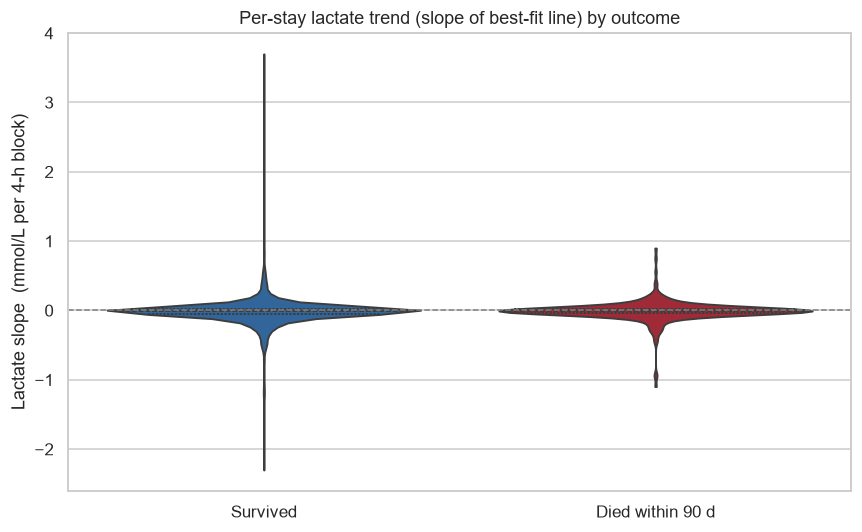

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=lactate_trend, x="died", y="lactate_slope",
               hue="died", palette={0: "#2166ac", 1: "#b2182b"}, legend=False,
               inner="quartile", cut=0, ax=ax)
ax.axhline(0, color="grey", lw=1, ls="--")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Survived", "Died within 90 d"])
ax.set_title("Per-stay lactate trend (slope of best-fit line) by outcome")
ax.set_xlabel(""); ax.set_ylabel("Lactate slope  (mmol/L per 4-h block)")
plt.tight_layout(); plt.show()


*Interpretation:* survivors cluster around a **flat-to-falling** lactate slope (resuscitation working);
non-survivors sit higher, with a fatter tail of **rising** lactate. A single trend number captures the *story*
that a single spot value cannot.

## ⚠️ Data leakage in time series — the section that saves your model

**Leakage** is when a feature secretly contains information you would **not** have at prediction time. It makes
your validation scores look brilliant and your real-world model useless. In time series it is easy to do by
accident. Three flavours:

1. **Imputing with the future / the global mean.** Forward-fill (`ffill`) carries the *last known* value forward —
   past only, **safe**. Filling a gap with the column's *global mean* leaks information from other patients and
   from later times.
2. **Whole-stay aggregates in an early-warning model.** `max` lactate over the *entire* stay is fine for
   predicting an *end-of-stay* outcome (Framing A), but using it to raise an alarm at hour 8 leaks the future —
   at hour 8 that maximum hasn't happened yet. The leakage-safe version is the **expanding** max (max *so far*).
3. **Any proxy of the outcome as a feature.** e.g. `died_in_hosp`, discharge disposition, a "comfort-care" order —
   these encode the answer. (We demonstrate this dramatically in Notebook 08.)

The one question that catches almost all of it: **"At the exact moment I make this prediction, would this number
already exist?"** If not, it's leakage.

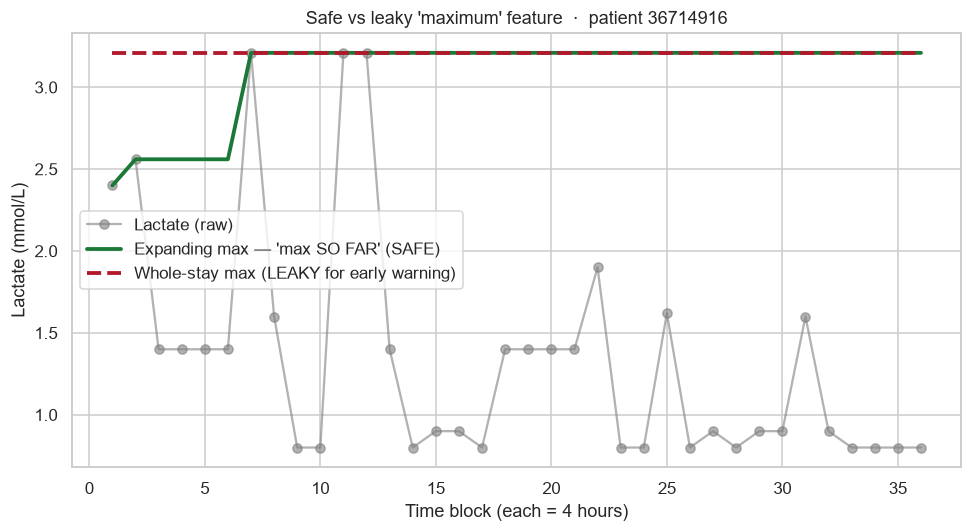

In [20]:
# Illustration: whole-stay max (LEAKY for early warning) vs expanding max (SAFE)
p = one(DEMO_DIED).copy()
p["lactate_wholestay_max"] = p["Arterial_lactate"].max()          # a single number, known only at the END
# lactate_expmax was built earlier with expanding().max() — the max SO FAR at each block

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(p["bloc"], p["Arterial_lactate"], marker="o", color="grey", alpha=0.6, label="Lactate (raw)")
ax.plot(p["bloc"], p["lactate_expmax"], color="#1b7837", lw=2.5, label="Expanding max — 'max SO FAR' (SAFE)")
ax.plot(p["bloc"], p["lactate_wholestay_max"], color="#b2182b", ls="--", lw=2.5,
        label="Whole-stay max (LEAKY for early warning)")
ax.set_title(f"Safe vs leaky 'maximum' feature  ·  patient {DEMO_DIED}")
ax.set_xlabel("Time block (each = 4 hours)"); ax.set_ylabel("Lactate (mmol/L)")
ax.legend()
plt.tight_layout(); plt.show()


*Interpretation:* the red dashed line is **flat at the final maximum from block 1** — a model would "know" the
patient's peak lactate before it ever occurred. The green line only ever reflects what has actually happened.
Same word ("maximum"), completely different honesty.

> **🧠 Clinical takeaway.** Whole-stay summaries are perfectly valid **for the question they match** (outcome of a
> completed stay). They become leakage only when you use them to predict something that happens *before the stay
> is over*. Always match the feature's time horizon to the prediction's.

## ✏️ Your turn

Time to build features yourself. Each exercise has a scaffold to fill in and a collapsible solution. Try before
you peek!

### ✏️ Exercise 1 — a lag-2 feature

Build `MeanBP_lag2`: each patient's MeanBP from **two** blocks earlier. Then display the first 6 rows of the demo
patient's `bloc`, `MeanBP`, `MeanBP_lag2`. (How many leading `NaN`s do you expect per patient?)

In [21]:
# TODO: create df["MeanBP_lag2"] using a grouped shift of 2
# df["MeanBP_lag2"] = ...
# one(DEMO_DIED)[["bloc", "MeanBP", "MeanBP_lag2"]].head(6)


<details><summary>💡 Show solution</summary>

```python
df["MeanBP_lag2"] = df.groupby("icustayid")["MeanBP"].shift(2)
one(DEMO_DIED)[["bloc", "MeanBP", "MeanBP_lag2"]].head(6)
```

The **first two** blocks of every patient are `NaN` — there is no "two blocks ago" yet. `shift(2)` respects
patient boundaries just like `shift(1)`.
</details>

### ✏️ Exercise 2 — a rolling ≈24-hour HR instability feature

Add `HR_roll6_std`: the standard deviation of heart rate over the last **6 blocks (≈24 h)**, per patient. Use the
`roll(...)` helper we defined. Then print how many rows have `HR_roll6_std > 15` (very unstable days).

In [22]:
# TODO: build a 6-block rolling std of HR with the roll() helper, then count unstable rows
# df["HR_roll6_std"] = roll(...)
# print("Unstable rows:", (df["HR_roll6_std"] > 15).sum())


<details><summary>💡 Show solution</summary>

```python
df["HR_roll6_std"] = roll("HR", 6, "std")
print("Unstable rows (HR_roll6_std > 15):", (df["HR_roll6_std"] > 15).sum())
```

`roll` already does the tricky `.reset_index(level=0, drop=True)` for you, so the result lines up with `df`.
A high rolling std means the heart rate was swinging wildly over the past day — often a bad sign.
</details>

### ✏️ Exercise 3 — count blocks with SpO₂ < 92

Build `desat_count`: the running number of blocks so far in which `SpO2 < 92` (mild desaturation), per patient —
the same boolean-then-`cumsum` pattern we used for hypotension. Then show the **maximum** `desat_count` reached by
the demo patient who died.

In [23]:
# TODO: flag SpO2 < 92, then a grouped cumsum; report the demo patient's peak count
# df["desat_flag"]  = ...
# df["desat_count"] = ...
# print("Peak desat_count for", DEMO_DIED, ":", ...)


<details><summary>💡 Show solution</summary>

```python
df["desat_flag"]  = (df["SpO2"] < 92).astype(int)
df["desat_count"] = df.groupby("icustayid")["desat_flag"].cumsum()
print("Peak desat_count for", DEMO_DIED, ":", int(one(DEMO_DIED)["desat_count"].max()))
```

Casting the boolean to `int` before `cumsum` keeps the running total as whole numbers. This "count of bad blocks
so far" is exactly the kind of leakage-safe early-warning feature real scores use.
</details>

### ✏️ Exercise 4 — per-stay SOFA trend by outcome

Compute each stay's **SOFA slope** with the `stay_slope` helper, attach the `morta_90` outcome, and compare the
mean slope for survivors vs non-survivors. Does organ failure trend *up* more steeply in those who die?

In [24]:
# TODO: groupby icustayid; aggregate SOFA with stay_slope and morta_90 with max; compare means
# sofa_trend = df.groupby("icustayid").agg(
#     sofa_slope = ("SOFA", stay_slope),
#     died       = ("morta_90", "max"),
# ).dropna()
# print(sofa_trend.groupby("died")["sofa_slope"].mean())


<details><summary>💡 Show solution</summary>

```python
sofa_trend = df.groupby("icustayid").agg(
    sofa_slope = ("SOFA", stay_slope),
    died       = ("morta_90", "max"),
).dropna()
print(sofa_trend.groupby("died")["sofa_slope"].mean().round(3))
```

Non-survivors show a **more positive** average SOFA slope — organ failure worsening over the stay — while
survivors trend flat or downward. A single slope number captures deterioration that a spot SOFA misses.
</details>

## 🏗️ Putting it together — build the patient-level table

Everything above was Framing **B** (per-timestep). Now we do Framing **A**: collapse each stay to **one row** of
summary features. The canonical builder below is what the whole course uses — it cleans temperature and vitals,
forward/back-fills **within each stay** (past-aware, no cross-patient leakage), then for each marker computes
`mean / min / max / last` and a few `delta`s. It is the **exact** function that produced the shipped
`sepsis_patients.csv`, so Notebooks 05–08 all start from the same table.

Read it once — you now understand every operation inside it.

In [25]:
def build_patient_table(ts):
    """Aggregate the 4-hourly time-series into ONE row per ICU stay.
       (This is exactly what Notebook 04 teaches you to build.)"""
    df = ts.copy()
    # clean temperature: prefer Celsius; repair obvious Fahrenheit-entry errors; drop impossible
    tf = df["Temp_F"].where((df["Temp_F"] >= 90) & (df["Temp_F"] <= 110))
    tc = df["Temp_C"].where((df["Temp_C"] >= 25) & (df["Temp_C"] <= 45))
    df["Temp_C_clean"] = tc.fillna((tf - 32) * 5/9)
    # impossible vitals -> NaN, then forward/back-fill WITHIN each stay
    for c, lo, hi in [("HR",20,300),("SysBP",40,300),("MeanBP",20,220),("RR",3,80),("SpO2",30,100)]:
        df[c] = df[c].where((df[c] >= lo) & (df[c] <= hi))
    g = df.groupby("icustayid", group_keys=False)
    vit = ["HR","SysBP","MeanBP","RR","SpO2","Temp_C_clean"]
    df[vit] = g[vit].apply(lambda x: x.ffill().bfill())
    # winsorise skewed labs so one stray value can't define a min/max
    for c in ["Arterial_lactate","Creatinine","BUN","WBC_count","Platelets_count","INR","Glucose"]:
        lo, hi = df[c].quantile(0.01), df[c].quantile(0.99)
        df[c] = df[c].clip(lo, hi)
    tv = ["HR","SysBP","MeanBP","RR","SpO2","Temp_C_clean","GCS","Creatinine","BUN",
          "Arterial_lactate","WBC_count","Platelets_count","Potassium","Sodium",
          "Albumin","INR","Arterial_pH","Shock_Index","SOFA","SIRS","PaO2_FiO2","Hb"]
    grp = df.groupby("icustayid")
    f = {}
    f["age"]=grp["age"].first(); f["gender"]=grp["gender"].first()
    f["elixhauser"]=grp["elixhauser"].first(); f["re_admission"]=grp["re_admission"].first().astype(int)
    f["weight_kg"]=grp["Weight_kg"].median(); f["n_blocs"]=grp.size(); f["los_hours"]=grp["bloc"].max()*4
    f["mechvent_ever"]=grp["mechvent"].max(); f["vaso_max"]=grp["max_dose_vaso"].max()
    f["fluid_balance_last"]=grp["cumulated_balance"].last(); f["urine_total"]=grp["output_step"].sum()
    for c in tv:
        f[f"{c}_mean"]=grp[c].mean(); f[f"{c}_min"]=grp[c].min()
        f[f"{c}_max"]=grp[c].max();  f[f"{c}_last"]=grp[c].last()
    for c in ["Creatinine","Arterial_lactate","SOFA","Shock_Index","GCS"]:
        f[f"{c}_delta"]=grp[c].last()-grp[c].first()
    X = pd.DataFrame(f); X["morta_90"]=grp["morta_90"].max(); X["died_in_hosp"]=grp["died_in_hosp"].max()
    return X.reset_index()

def load_patients():
    p = _find("sepsis_patients.csv")
    if p:
        print(f"✓ loaded {p}"); return pd.read_csv(p)
    print("sepsis_patients.csv not found — building it from the time-series file…")
    return build_patient_table(load_csv("sepsis_timeseries.csv"))


Run the builder on our (already sorted) time-series. Note it takes a **fresh** view of the original columns —
the extra feature columns we added above are simply ignored.

In [26]:
patients = build_patient_table(df)
print("Patient table shape:", patients.shape, " (one row per ICU stay)")
print("90-day mortality rate:", round(patients["morta_90"].mean(), 3))
patients.head()


Patient table shape: (1696, 107)  (one row per ICU stay)
90-day mortality rate: 0.182


,icustayid,age,gender,elixhauser,re_admission,weight_kg,n_blocs,los_hours,mechvent_ever,vaso_max,fluid_balance_last,urine_total,HR_mean,HR_min,HR_max,HR_last,SysBP_mean,SysBP_min,SysBP_max,SysBP_last,MeanBP_mean,MeanBP_min,MeanBP_max,MeanBP_last,RR_mean,RR_min,RR_max,RR_last,SpO2_mean,SpO2_min,SpO2_max,SpO2_last,Temp_C_clean_mean,Temp_C_clean_min,Temp_C_clean_max,Temp_C_clean_last,GCS_mean,GCS_min,GCS_max,GCS_last,Creatinine_mean,Creatinine_min,Creatinine_max,Creatinine_last,BUN_mean,BUN_min,BUN_max,BUN_last,Arterial_lactate_mean,Arterial_lactate_min,Arterial_lactate_max,Arterial_lactate_last,WBC_count_mean,WBC_count_min,WBC_count_max,WBC_count_last,Platelets_count_mean,Platelets_count_min,Platelets_count_max,Platelets_count_last,Potassium_mean,Potassium_min,Potassium_max,Potassium_last,Sodium_mean,Sodium_min,Sodium_max,Sodium_last,Albumin_mean,Albumin_min,Albumin_max,Albumin_last,INR_mean,INR_min,INR_max,INR_last,Arterial_pH_mean,Arterial_pH_min,Arterial_pH_max,Arterial_pH_last,Shock_Index_mean,Shock_Index_min,Shock_Index_max,Shock_Index_last,SOFA_mean,SOFA_min,SOFA_max,SOFA_last,SIRS_mean,SIRS_min,SIRS_max,SIRS_last,PaO2_FiO2_mean,PaO2_FiO2_min,PaO2_FiO2_max,PaO2_FiO2_last,Hb_mean,Hb_min,Hb_max,Hb_last,Creatinine_delta,Arterial_lactate_delta,SOFA_delta,Shock_Index_delta,GCS_delta,morta_90,died_in_hosp
0,30003226,67,0,4,0,91.8,12,48,0,0.00,3679.19,625.0,73.310833,64.00,84.20,84.20,137.518333,114.75,169.50,137.00,95.471667,87.25,106.86,90.8,15.577500,12.75,20.80,20.80,96.670833,93.00,99.50,97.00,37.484167,36.67,37.98,36.67,15.000000,15.0,15.0,15.0,11.449000,0.6,12.4388,12.4388,54.495000,13.0,64.0,58.0,1.061667,0.6,2.00,1.7,7.770000,6.60,9.3000,6.6,220.833333,183.00,357.0,183.0,5.410833,2.9,6.80,5.4,135.293333,132.00,149.0,132.0,2.858333,2.30,3.3,3.3,1.439167,1.00,3.1,3.1,7.345833,7.22,7.45,7.32,0.540833,0.39,0.65,0.61,4.833333,1,7,5,0.166667,0,1,1,387.047500,177.78,1342.86,200.00,7.066667,6.6,8.00,6.6,11.8388,-0.30,4,0.02,0.0,0,0
1,30004576,36,0,2,0,87.0,7,28,0,0.00,-2170.00,2350.0,95.707143,89.00,108.33,89.00,126.027143,121.00,138.83,121.00,82.482857,79.00,88.86,79.0,16.568571,12.40,24.00,24.00,97.645714,96.00,99.00,99.00,37.077143,36.44,37.74,36.44,11.571429,3.0,15.0,3.0,0.700000,0.4,0.9000,0.9000,12.857143,8.0,21.0,12.0,2.328571,0.7,3.30,3.3,19.104657,6.10,81.3326,6.1,325.857143,227.00,357.0,357.0,3.842857,3.5,4.40,3.8,139.571429,136.00,143.0,140.0,3.300000,2.70,3.5,3.5,1.357143,1.10,1.4,1.4,7.442857,7.35,7.48,7.48,0.758571,0.74,0.79,0.74,2.714286,0,5,5,1.285714,1,2,1,440.010000,188.89,848.30,338.10,8.648571,8.6,8.73,8.6,0.4000,2.60,5,-0.01,-12.0,0,0
2,30004811,66,0,4,0,63.5,14,56,1,0.36,1798.03,5945.0,83.140714,74.96,96.00,96.00,105.329286,90.57,127.75,111.00,70.336429,59.17,86.57,71.0,18.700000,11.83,25.00,25.00,98.383571,96.83,99.91,97.00,36.904286,36.63,37.22,37.22,12.307857,6.0,15.0,6.0,1.116429,0.6,5.8000,0.9000,14.980714,11.0,32.0,17.0,2.182857,0.7,3.00,1.4,7.070714,4.25,18.5000,6.9,161.647143,104.00,235.0,157.0,4.555714,3.6,5.91,4.2,135.970000,134.00,137.0,135.0,2.740000,2.33,4.0,4.0,1.316429,1.03,1.4,1.2,7.452143,7.37,7.47,7.47,0.797143,0.59,0.93,0.86,4.571429,1,8,5,0.500000,0,2,2,342.733571,48.04,933.80,292.86,9.346429,8.0,10.41,10.0,0.1000,-1.60,2,0.27,-9.0,0,0
3,30009596,77,1,4,0,72.0,9,36,0,0.00,-1650.00,2750.0,60.840000,53.00,83.89,69.33,169.900000,159.25,185.18,174.83,98.926667,87.25,113.33,102.0,15.705556,14.00,18.00,17.00,95.125556,92.40,97.22,96.00,36.977778,36.89,37.17,36.91,12.888889,6.0,15.0,6.0,0.911111,0.6,2.2000,0.7000,15.888889,8.0,31.0,11.0,1.364444,0.7,2.78,1.0,8.900000,6.40,14.3000,10.0,279.185556,65.67,466.0,466.0,3.988889,3.5,4.40,4.1,141.185556,134.00,147.0,147.0,3.326667,2.70,3.9,3.9,1.333333,1.10,2.3,1.1,7.430000,7.32,7.51,7.49,0.357778,0.30,0.51,0.40,3.111111,1,8,3,0.333333,0,1,0,404.220000,134.68,942.71,407.64,10.907778,7.5,12.30,12.3,0.0000,-1.78,1,0.06,-9.0,0,0
4,30011748,70,0,2,0,91.0,5,20,0,0.00,50.00,950.0,71.090000,67.43,75.12,75.12,141.908000,134.86,148.88,148.88,97.818000,90.29,105

### 💾 Save it for the modelling notebooks

Notebooks 05–08 call `load_patients()`, which reads `data/sepsis_patients.csv`. That file already ships with the
course, so **here we save our freshly-built copy under a new name** and confirm it matches the shipped one — a nice
sanity check that our pipeline reproduces the official table. (In your own project you'd simply save it as
`sepsis_patients.csv`; on Colab it writes to the session, which is fine.)

In [27]:
import os
os.makedirs("data", exist_ok=True)
out_path = "data/sepsis_patients_rebuilt.csv"
patients.to_csv(out_path, index=False)
print(f"✓ saved {out_path}  ({patients.shape[0]} rows, {patients.shape[1]} columns)")

# sanity check: does our rebuild match the shipped patient table?
shipped = load_patients()   # reads the shipped data/sepsis_patients.csv
print("Shipped table shape :", shipped.shape)
print("Rebuilt table shape :", patients.shape)
print("Same set of columns :", set(shipped.columns) == set(patients.columns))
print("Same number of stays:", shipped["icustayid"].nunique() == patients["icustayid"].nunique())


✓ saved data/sepsis_patients_rebuilt.csv  (1696 rows, 107 columns)
✓ loaded data/sepsis_patients.csv
Shipped table shape : (1696, 107)
Rebuilt table shape : (1696, 107)
Same set of columns : True
Same number of stays: True


> **🧠 Clinical takeaway.** The patient table is a *lossy summary* — it trades the rich timeline for a tidy
> rectangle a model can learn from. The art is choosing summaries that keep the clinically meaningful signal
> (trend `delta`s, worst-case `min`/`max`, typical `mean`). Everything you engineered by hand today is baked into
> this one function.

## ✅ Recap

- **Sort first.** `sort_values(["icustayid","bloc"])` before *any* time-series transform — otherwise "the previous
  block" is nonsense.
- **Always group by `icustayid`.** Every transform (`shift`, `diff`, `rolling`, `cumsum`, `expanding`) must respect
  patient boundaries so you never borrow a neighbour's data.
- **The toolbox:**
  - **Lag** `shift(k)` — value k blocks ago
  - **Delta / rate** `diff()`, `diff()/4` — change, and change per hour
  - **Rolling** `rolling(k).mean()/.std()/.min()` — smoothing & instability over a fixed window
  - **Cumulative** `cumsum()`, `cummax()` — running totals / worst-so-far
  - **Expanding** `expanding().mean()` — leakage-safe "average so far"
  - **Time-since & counts** — hours since admit, cumulative bad-block tallies, fraction on treatment
  - **Trend** last−first, or `np.polyfit` slope over the stay
- **Two framings, one question:** whole-stay features (Framing A) answer end-of-stay questions; per-timestep
  features (Framing B) power early warning — and must use **only the past**.
- **Leakage check:** *"At the moment of prediction, would this number already exist?"* If not, it's a leak.
- **`build_patient_table`** collapses the timeline to one clean row per stay — the foundation of Notebooks 05–08.

## ➡️ Next

**Notebook 05 — Your first predictive models.** We take the patient table you just built, split it **by patient**,
and train baseline, logistic-regression, random-forest and XGBoost models to predict 90-day mortality — then
compare them honestly with ROC-AUC. See you there! 🚀